# Data class usage


In [1]:
from ArtFire.Data.SimulatedDataset import SimulatedData

split=(0.6,0.2,0.2)

train_dataset = SimulatedData(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="train",
    horizon=50,
    normalize=True,
)

val_dataset = SimulatedData(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="val",
    horizon=50,
    stats=train_dataset.get_stats(),
)

test_dataset = SimulatedData(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="test",
    horizon=50,
    stats=train_dataset.get_stats(),
)

### Now you can initialize a standard torch dataloader

In [2]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
)


#   x_t -> x_t+1,..... x_t+50
#   x_t+1  -> x_t+2,...

# this is the correct configuration for best performance, not available in jupyter notebook
#val_loader = DataLoader(
#    val_dataset,
#    batch_size=8,
 #   shuffle=False,
#    num_workers=4,
 #   pin_memory=True,
#    persistent_workers=True,
#)

### Display a gif of the horizon frames

On the left x_t, on the right the frames to predict

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

batch = next(iter(train_loader))

x_t = batch["x_t"][0].cpu()      # [C, H, W]
y_seq = batch["y_seq"][0].cpu()  # [H, C, H, W]
channel = 0

vmin = min(x_t[channel].min().item(), y_seq[:, channel].min().item())
vmax = max(x_t[channel].max().item(), y_seq[:, channel].max().item())

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
ax_left, ax_right = axes

def update(frame):
    ax_left.clear()
    ax_right.clear()

    # Left: x_t fixed
    ax_left.imshow(
        x_t[channel],
        cmap="inferno",
        interpolation="nearest",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax_left.set_title("x_t")
    ax_left.axis("off")

    # Right: future sequence animated
    img = y_seq[frame, channel]
    ax_right.imshow(
        img,
        cmap="inferno",
        interpolation="nearest",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax_right.set_title(f"x_t+{frame+1}")
    ax_right.axis("off")

ani = animation.FuncAnimation(
    fig,
    update,
    frames=y_seq.shape[0],
    interval=100,
)

plt.close()
HTML(ani.to_jshtml())

Quick check to verify if original dataset and the images from the loader are the same

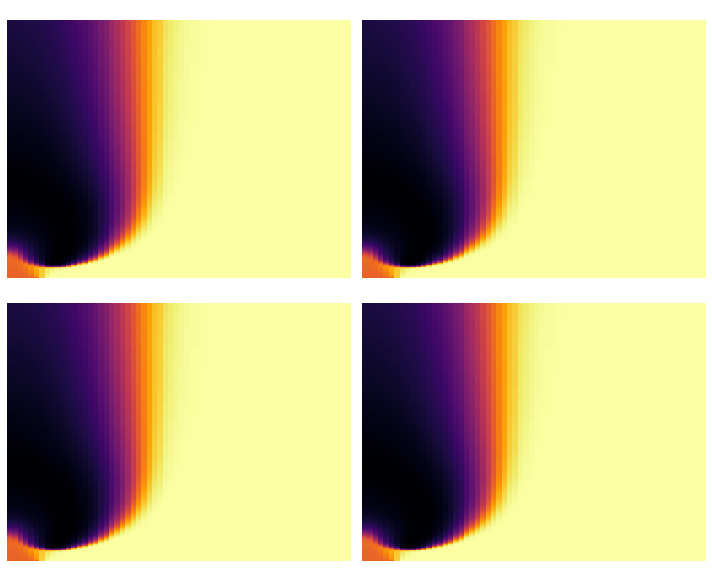

x_t equal: True
x_t+1 equal: True
max diff x_t: 5.9587363709923125e-08
max diff x_t+1: 5.9528304285905165e-08


In [4]:
import numpy as np

data = np.load("D_t2001_f13_z256_x64.npy")

dataset = SimulatedData(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=(0.7, 0.15, 0.15),
    mode="train",
    horizon=10,
    normalize=False,
)

loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
batch = next(iter(loader))

x_t = batch["x_t"][0].numpy()
y_seq = batch["y_seq"][0].numpy()

channel = 0
t0 = 0

raw_xt = data[t0, channel]
raw_t1 = data[t0 + 1, channel]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].imshow(raw_xt, cmap="inferno", interpolation="nearest", aspect="auto")
axs[0, 0].set_title("Raw x_t")

axs[0, 1].imshow(x_t[channel], cmap="inferno", interpolation="nearest", aspect="auto")
axs[0, 1].set_title("Dataset x_t")

axs[1, 0].imshow(raw_t1, cmap="inferno", interpolation="nearest", aspect="auto")
axs[1, 0].set_title("Raw x_{t+1}")

axs[1, 1].imshow(y_seq[0, channel], cmap="inferno", interpolation="nearest", aspect="auto")
axs[1, 1].set_title("Dataset y_seq[0]")

for ax in axs.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

print("x_t equal:", np.allclose(raw_xt, x_t[channel]))
print("x_t+1 equal:", np.allclose(raw_t1, y_seq[0, channel]))
print("max diff x_t:", np.abs(raw_xt - x_t[channel]).max())
print("max diff x_t+1:", np.abs(raw_t1 - y_seq[0, channel]).max())

Custom Convolutional Block

In [5]:
from ArtFire.DL.Models.convolution import CNNblock

In [6]:
cnn_block=CNNblock(input_channels=x_t.shape[0], output_channels=64, hidden_channels=[32], dim=2, paddings=0, strides=2)

In [7]:
cnn_block

CNNblock(
  (backbone): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
  )
)

Apply the convolutional block to an input from the data loader

In [8]:
x=next(iter(train_loader))["x_t"]
print(x.shape)
x=cnn_block(x)
x.shape

torch.Size([8, 13, 256, 64])


torch.Size([8, 64, 63, 15])

At this point, consider that the H dimension is the time, permute to have [B,H,C,W] convolutional block


In [9]:
B=8
C=64
H=63
W=15
x=x.permute((0,2,1,3))
x = x.unsqueeze(2)               # → [B, H, 1, C, W]
x = x.reshape(B*H, 1, C, W)
x.shape

torch.Size([504, 1, 64, 15])

now we have batches of 63 tokens, each of shape 64x15

apply a second convolution to vectorize each 2d-token


In [10]:
import torch.nn as nn
cnn_block_2=CNNblock(input_channels=1, output_channels=64, hidden_channels=[32], dim=2, paddings=0, strides=2)
model=nn.Sequential(
    cnn_block_2,
    nn.AdaptiveAvgPool2d(1)
    )
model

Sequential(
  (0): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (1): AdaptiveAvgPool2d(output_size=1)
)

In [11]:
x=model(x)
x.shape

torch.Size([504, 64, 1, 1])

In [12]:
x=x.reshape((B,H,-1))
x.shape

torch.Size([8, 63, 64])

Now we have 63 tokens, each of them is a vector of dim 64. Now we can apply a transformer

Overall model is the following


In [60]:
class ConvEncoder(nn.Module):
    def __init__(self, config_spatial_conv, config_temporal_conv):
        super().__init__()
        self.sp_conv=CNNblock(**config_spatial_conv)
        self.t_conv=CNNblock(**config_temporal_conv)
        #self.pool=nn.AdaptiveAvgPool2d(output_size=1)

    def forward(self,x):
        x=self.sp_conv(x)
        B,C,H,W= x.shape
        x=x.permute((0,2,1,3)) # -> B,H,C,W
        x = x.unsqueeze(2)  # -> B,H,1,C,W
        x = x.reshape(B*H, 1, C, W)  # -> B*H,1,C,W
        x=self.t_conv(x)
        x=x.view(B,H,*x.shape[1:])
        return x.flatten(start_dim=2)#.reshape((B,H,-1))


In [65]:
x_t=next(iter(train_loader))["x_t"]

spatial_conv_config={"input_channels":x_t.shape[1], "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0, "strides":2}
temporal_conv_config ={"input_channels":1, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0,
                       "strides":2}

CAEenc=ConvEncoder(spatial_conv_config, temporal_conv_config)

CAEenc


ConvEncoder(
  (sp_conv): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (t_conv): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
)

In [66]:
y=CAEenc(x_t)
y.shape

torch.Size([8, 63, 2880])

Now we have 63 tokens, each of them is a vector of dim 64. Now we can apply a transformer

Apply transpose convolution to reconstruct input image

In [67]:
from ArtFire.DL.Models.convolution import TCNNblock
class ConvDecoder(nn.Module):
    def __init__(self, config_spatial_tconv, config_temporal_tconv, no_flatten_dim):
        super().__init__()
        self.sp_tconv=TCNNblock(**config_spatial_tconv)
        self.t_tconv=TCNNblock(**config_temporal_tconv)
        self.C2, self.H2 , self.W2=no_flatten_dim



    def forward(self,x):
        B, H = x.shape[:2]
        x=x.view(B* H, self.C2, self.H2, self.W2)
        x=self.t_tconv(x)
        x=x.view(B, H,*x.shape[1:])
        x=x.squeeze(dim=2)
        x=x.permute(0,2,1,3)
        return self.sp_tconv(x)




In [41]:


spatial_tconv_config={"input_channels":64, "output_channels":13, "hidden_channels":[32], "dim":2, "paddings":0,
                      "output_paddings":[(0, 0), (1, 0)],"strides":2}
temporal_tconv_config ={"input_channels":64, "output_channels":1, "hidden_channels":[32], "dim":2, "paddings":0,"output_paddings":[(0, 0), (1, 0)], "strides":2}



CAEdec=ConvDecoder(spatial_tconv_config, temporal_tconv_config, no_flatten_dim=(64,15,3))
CAEdec




ConvDecoder(
  (sp_tconv): TCNNblock(
    (backbone): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): ConvTranspose2d(32, 13, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0), bias=False)
      (4): BatchNorm2d(13, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (t_tconv): TCNNblock(
    (backbone): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0), bias=False)
      (4): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate=

In [42]:
CAEdec(y).shape

NameError: name 'y' is not defined

In [1]:
from ArtFire.DL.Models.CAE import CAE, ConvEncoder, ConvDecoder
from ArtFire.Data.CAEDataset import CAEDataset
from ArtFire.DL.Optimization.optimizers import build_optimizer, build_parameter_groups
from pytorch_scheduler.scheduler.polynomial import PolynomialScheduler
from pytorch_scheduler.base.warmup import WarmupScheduler

In [3]:
from torch.utils.data import DataLoader

split = (0.7, 0.15, 0.15)

train_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="train",
    normalize=True,
)

val_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="val",
    normalize=True,
    stats=train_dataset.get_stats(),
)
test_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="test",
    normalize=True,
    stats=train_dataset.get_stats(),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

batch = next(iter(train_loader))
print(batch["x"].shape)  # [B, 13, 256, 64]
print(batch["y"].shape)  # [B, 13, 256, 64]

torch.Size([8, 13, 256, 64])
torch.Size([8, 13, 256, 64])


In [12]:
spatial_conv_config={"input_channels":13, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0, "strides":2}
temporal_conv_config ={"input_channels":1, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0,
                       "strides":2}

CAEenc=ConvEncoder(spatial_conv_config, temporal_conv_config)

spatial_tconv_config={"input_channels":64, "output_channels":13, "hidden_channels":[32], "dim":2, "paddings":0,
                      "output_paddings":[(0, 0), (1, 1)],"strides":2}
temporal_tconv_config ={"input_channels":64, "output_channels":1, "hidden_channels":[32], "dim":2, "paddings":0,"output_paddings":[(0, 0), (1, 0)], "strides":2}



CAEdec=ConvDecoder(spatial_tconv_config, temporal_tconv_config, no_flatten_dim=(64,15,3))




CAEmodel=CAE(CAEenc,CAEdec)
CAEmodel

CAE(
  (ConvEncoder): ConvEncoder(
    (sp_conv): CNNblock(
      (backbone): Sequential(
        (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
      )
    )
    (t_conv): CNNblock(
      (backbone): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
      )
    )
  )
 

In [13]:


import torch
import torch.nn as nn
from tqdm import tqdm



def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader):
        x = batch["x"].to(device)   # CAEDataset
        y = batch["y"].to(device)

        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        y_hat = model(x)
        loss = criterion(y_hat, y)

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CAEmodel.to(device)

parameters_groups=build_parameter_groups(CAEmodel, 0.0001, 0.00005)
optimizer=build_optimizer(params=parameters_groups[1],
   config= {
    "name":"adamw",
    "lr":1e-3,
    "weight_decay":1e-5,
    "use_lookahead": True}
)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#scheduler= PolynomialScheduler(optimizer=optimizer, total_steps=20, power=1, min_lr=1e-7)
#warmup_scheduler=WarmupScheduler(optimizer, scheduler, warmup_steps=5, warmup_type="linear")


criterion = nn.MSELoss()
num_epochs = 20

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1:03d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_cae.pt")

100%|██████████| 175/175 [00:12<00:00, 13.74it/s]


Epoch 001 | train loss: 1.289762 | val loss: 0.371004


100%|██████████| 175/175 [00:12<00:00, 13.52it/s]


Epoch 002 | train loss: 0.194304 | val loss: 0.102426


100%|██████████| 175/175 [00:12<00:00, 13.99it/s]


...

100%|██████████| 175/175 [00:12<00:00, 13.96it/s]


Epoch 004 | train loss: 0.063549 | val loss: 0.058729


100%|██████████| 175/175 [00:12<00:00, 14.00it/s]


Epoch 005 | train loss: 0.059255 | val loss: 0.056414


 95%|█████████▍| 166/175 [00:11<00:00, 13.86it/s]

In [10]:
model.load_state_dict(torch.load("best_cae.pt", map_location=device))
test_loss = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.6f}")

C:\Users\carlo\AppData\Local\Temp\ipykernel_17260\2951192782.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cae.pt", map_location

Test loss: 0.050286


In [1]:
from ArtFire.DL.DL import CustomMLP
from ArtFire.DL.Optimization import build_optimizer, build_parameter_groups
from pytorch_scheduler.scheduler.polynomial import PolynomialScheduler
from pytorch_scheduler.base.warmup import WarmupScheduler
import torch
import matplotlib.pyplot as plt


Linear(in_features=10, out_features=0, bias=True)

In [2]:
model=CustomMLP(input_dim=100, output_dim=10, hidden_layers=[64,32], dropout_p=0.1, normalization="Batch-Norm", activation="leaky_relu", initialization="default")


In [3]:
model.network

Sequential(
  (0): Linear(in_features=100, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Dropout(p=0.1, inplace=False)
  (8): Linear(in_features=32, out_features=10, bias=True)
)

In [4]:
torch.mean(model.network[0].weight[1])

tensor(0.0027, grad_fn=<MeanBackward0>)

# Split Parameters into regularized ones and non-regularized ones
Do not regularize biases and normalization parameters

In [5]:
parameters_groups=build_parameter_groups(model, 0.0001, 0.00005)
parameters_groups

([['network.0.weight', 'network.4.weight', 'network.8.weight'],
  ['network.0.bias',
   'network.1.weight',
   'network.1.bias',
   'network.4.bias',
   'network.5.weight',
   'network.5.bias',
   'network.8.bias']],
 [{'params': [Parameter containing:
    tensor([[ 0.0554, -0.0103, -0.0876,  ..., -0.0748,  0.0620,  0.0327],
            [ 0.0760,  0.0444, -0.0245,  ...,  0.0129,  0.0476, -0.0356],
            [ 0.0767,  0.0874, -0.0211,  ...,  0.0859, -0.0785, -0.0904],
            ...,
            [ 0.0802,  0.0407,  0.0686,  ..., -0.0968,  0.0748, -0.0315],
            [-0.0184, -0.0967,  0.0771,  ..., -0.0899, -0.0223,  0.0444],
            [ 0.0092,  0.0002,  0.0816,  ..., -0.0060, -0.0120,  0.0883]],
           requires_grad=True),
    Parameter containing:
    tensor([[ 0.0447, -0.0771,  0.0885,  ...,  0.0683,  0.0433, -0.0239],
            [-0.0720,  0.0388, -0.1128,  ...,  0.0141,  0.0239, -0.0432],
            [ 0.0213, -0.0298, -0.0759,  ..., -0.0093, -0.0508,  0.0178],
     

# Set-up an AdamW optimizer with lookahead

In [36]:
optimizer=build_optimizer(params=parameters_groups[1],
   config= {
    "name":"adamw",
    "lr":1e-3,
    "weight_decay":1e-4,
    "use_lookahead": True}
)

In [37]:
optimizer

Lookahead (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 1e-07
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 1e-07
    maximize: False
    weight_decay: 0.0
)

# Set-up a lr scheduler

In [38]:
scheduler= PolynomialScheduler(optimizer=optimizer, total_steps=10000, power=1, min_lr=1e-7)

In [39]:
warmup_scheduler=WarmupScheduler(optimizer, scheduler, warmup_steps=1000, warmup_type="linear")

In [40]:
lrs=[]
for step in range(10000):
    lrs.append(optimizer.param_groups[0]["lr"])
    warmup_scheduler.step()

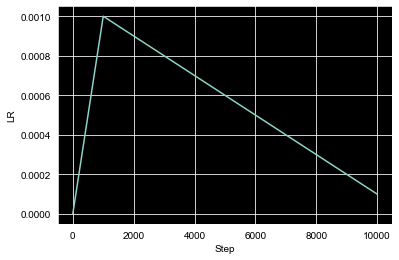

In [41]:
plt.plot(lrs)

plt.xlabel("Step", color="black")
plt.ylabel("LR", color="black")

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(True)

plt.show()